# Analisis Spatial Scale — Simulasi dan Visualisasi Lengkap

Notebook ini menguji augmentasi **Spatial Scale** dari berbagai sudut pandang:

| Cell | Konten |
|------|--------|
| 4 | Simulasi perhitungan 5 frame berurutan dalam **1 epoch** |
| 5 | Simulasi perhitungan **1 frame** yang sama di 4 epoch berbeda |
| 6 | Visualisasi 5 frame berurutan — baseline vs scale pada **1 epoch** |
| 7 | Visualisasi 5 frame berurutan — baseline vs scale pada **3 epoch** |
| 8 | Visualisasi distribusi faktor skala |


## 1. Setup

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

# Frame yang dianalisis
START_FRAME  = 33   # frame awal untuk rangkaian 5 frame
TARGET_FRAME = 35   # frame tunggal untuk simulasi multi-epoch
SELECTED_ID  = 'P1_S15_R1'
FRAME_INDICES = list(range(START_FRAME, START_FRAME + 5))  # [33, 34, 35, 36, 37]

# MediaPipe hand skeleton connections (local index 0–20)
HAND_CONNS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17)
]

LANDMARK_NAMES = {
    0  : 'Wrist',
    8  : 'Index Tip',
    12 : 'Middle Tip',
}

COLOR_BASELINE = '#2166AC'
COLOR_SCALE    = '#D6604D'
EPOCH_COLORS   = ['#E07B39', '#8B5E9E', '#2E8B57']

print(f'Frame yang dianalisis : {FRAME_INDICES}')
print(f'Frame target (tunggal): {TARGET_FRAME}')

Frame yang dianalisis : [33, 34, 35, 36, 37]
Frame target (tunggal): 35


## 2. Definisi Kelas `Scale`

In [2]:
class Scale(object):
    """
    Scale skeleton sequences by applying random scaling factors.

    Args:
        scale_range (tuple): Range of scaling factors (min, max).
    """

    def __init__(self, scale_range=(0.8, 1.2)) -> None:
        self.scale_range = scale_range

    def __call__(self, skeleton, **kwargs):
        T = skeleton.shape[0]
        scales = np.random.uniform(*self.scale_range, size=T)
        scaled_skeleton = skeleton * scales[:, np.newaxis, np.newaxis]
        return scaled_skeleton


scale_aug = Scale(scale_range=(0.8, 1.2))
print(f'Scale augmentor: range = {scale_aug.scale_range}')
print()
print('Catatan penting:')
print('  scales = np.random.uniform(0.8, 1.2, size=T)  → shape (T,)')
print('  skeleton * scales[:, np.newaxis, np.newaxis]  → broadcast (T,1,1) ke (T,K,C)')
print('  ∴ Semua keypoint dalam satu frame mendapat faktor skala yang SAMA')
print('    Faktor skala berbeda ANTAR frame dan ANTAR epoch')

Scale augmentor: range = (0.8, 1.2)

Catatan penting:
  scales = np.random.uniform(0.8, 1.2, size=T)  → shape (T,)
  skeleton * scales[:, np.newaxis, np.newaxis]  → broadcast (T,1,1) ke (T,K,C)
  ∴ Semua keypoint dalam satu frame mendapat faktor skala yang SAMA
    Faktor skala berbeda ANTAR frame dan ANTAR epoch


## 3. Load Data

In [3]:
with open('../data/pickle/pose_bisindo.pkl', 'rb') as f:
    dataset = pickle.load(f)

assert SELECTED_ID in dataset, f'{SELECTED_ID} tidak ditemukan.'

kp_data  = dataset[SELECTED_ID]['keypoints']  # (T, 86, 2)
skeleton = kp_data.copy()

assert max(FRAME_INDICES) < len(skeleton), \
    f'Frame {max(FRAME_INDICES)} melebihi panjang video ({len(skeleton)})'

print(f'Video  : {SELECTED_ID}')
print(f'Shape  : {skeleton.shape}  →  T={skeleton.shape[0]} frame, K=86 keypoint, C=2 koordinat')

Video  : P1_S15_R1
Shape  : (115, 86, 2)  →  T=115 frame, K=86 keypoint, C=2 koordinat


## 4. Simulasi Perhitungan — 5 Frame Berurutan dalam 1 Epoch

Menunjukkan bahwa setiap frame mendapat $s_t$ yang **berbeda-beda** meski dalam satu pemanggilan `Scale()`.

In [4]:
np.random.seed(42)
scaled_epoch1 = scale_aug(skeleton)   # satu pemanggilan = satu epoch

# Rekonstruksi s_t per frame dari hasil bagi
def get_scale_factor(orig_seq, scaled_seq, frame_idx, kp_idx=21):
    """Rekonstruksi faktor skala dari hasil bagi koordinat."""
    orig_val   = orig_seq[frame_idx, kp_idx, 0]
    scaled_val = scaled_seq[frame_idx, kp_idx, 0]
    return scaled_val / orig_val if orig_val != 0 else float('nan')

print('SIMULASI: 5 Frame Berurutan dalam 1 Epoch')
print('=' * 112)
print(f'Pemanggilan: scaled_seq = scale_aug(skeleton)  →  scales ~ U(0.8, 1.2), size=T={skeleton.shape[0]}')
print('=' * 112)
header = (
    f"{'Frame':<8}"
    f"{'s_t (faktor skala)':<22}"
    f"{'Landmark':<14}"
    f"{'Koordinat Awal (x, y)':<28}"
    f"{'× s_t':<12}"
    f"{'Koordinat Hasil (x, y)'}"
)
print(header)
print('-' * 112)

for fi in FRAME_INDICES:
    s_t = get_scale_factor(skeleton, scaled_epoch1, fi)
    first = True
    for idx, name in LANDMARK_NAMES.items():
        x0, y0 = skeleton[fi, 21 + idx]
        xs, ys = scaled_epoch1[fi, 21 + idx]
        frame_col = str(fi) if first else ''
        scale_col = f'{s_t:.4f}' if first else ''
        print(
            f"{frame_col:<8}"
            f"{scale_col:<22}"
            f"{name:<14}"
            f"({x0:.4f}; {y0:.4f})".ljust(28) +
            f"× {s_t:.4f}".ljust(12) +
            f"({xs:.4f}; {ys:.4f})"
        )
        first = False
    print('-' * 112)

print()
print('→ Setiap frame mendapat s_t berbeda (faktor skala independen per frame)')
print('→ Dalam satu frame, SEMUA keypoint dikalikan s_t yang sama')

SIMULASI: 5 Frame Berurutan dalam 1 Epoch
Pemanggilan: scaled_seq = scale_aug(skeleton)  →  scales ~ U(0.8, 1.2), size=T=115
Frame   s_t (faktor skala)    Landmark      Koordinat Awal (x, y)       × s_t       Koordinat Hasil (x, y)
----------------------------------------------------------------------------------------------------------------
33      1.1796                Wrist         (0.3741; 0.5858)× 1.1796    (0.4413; 0.6910)
                              Index Tip     (0.4364; 0.3067)× 1.1796    (0.5147; 0.3618)
                              Middle Tip    (0.3991; 0.2745)× 1.1796    (0.4708; 0.3238)
----------------------------------------------------------------------------------------------------------------
34      1.1863                Wrist         (0.3734; 0.5835)× 1.1863    (0.4429; 0.6922)
                              Index Tip     (0.4337; 0.3060)× 1.1863    (0.5145; 0.3630)
                              Middle Tip    (0.3969; 0.2734)× 1.1863    (0.4708; 0.3244)
--------

## 5. Simulasi Perhitungan — 1 Frame yang Sama di 4 Epoch

Menunjukkan bahwa frame yang **sama** mendapat $s_t$ yang **berbeda** di setiap epoch.

In [6]:
N_EPOCHS     = 4
scaled_seqs  = [scaled_epoch1]          # epoch 1 sudah ada
epoch_s_list = [get_scale_factor(skeleton, scaled_epoch1, TARGET_FRAME)]

for _ in range(N_EPOCHS - 1):
    seq = scale_aug(skeleton)
    scaled_seqs.append(seq)
    epoch_s_list.append(get_scale_factor(skeleton, seq, TARGET_FRAME))

print(f'SIMULASI: Frame {TARGET_FRAME} di 4 Epoch Berbeda')
print('=' * 112)
print(f'Frame yang sama (t={TARGET_FRAME}) dipanggil Scale() sebanyak {N_EPOCHS} kali (simulasi {N_EPOCHS} epoch)')
print('=' * 112)
header = (
    f"{'Epoch':<8}"
    f"{f's_t (frame {TARGET_FRAME})':<22}"
    f"{'Landmark':<14}"
    f"{'Koordinat Awal (x, y)':<28}"
    f"{'× s_t':<12}"
    f"{'Koordinat Hasil (x, y)'}"
)
print(header)
print('-' * 112)

for ep_i, (seq, s_t) in enumerate(zip(scaled_seqs, epoch_s_list), 1):
    first = True
    for idx, name in LANDMARK_NAMES.items():
        x0, y0 = skeleton[TARGET_FRAME, 21 + idx]
        xs, ys = seq[TARGET_FRAME, 21 + idx]
        epoch_col = str(ep_i) if first else ''
        scale_col = f'{s_t:.4f}' if first else ''
        print(
            f"{epoch_col:<8}"
            f"{scale_col:<22}"
            f"{name:<14}"
            f"({x0:.4f}; {y0:.4f})".ljust(28) +
            f"× {s_t:.4f}".ljust(12) +
            f"({xs:.4f}; {ys:.4f})"
        )
        first = False
    print('-' * 112)

print()
print(f'→ Frame {TARGET_FRAME} yang sama mendapat s_t berbeda di setiap epoch')
print('→ Koordinat awal (x, y) selalu sama — yang berubah hanya faktor s_t')

SIMULASI: Frame 35 di 4 Epoch Berbeda
Frame yang sama (t=35) dipanggil Scale() sebanyak 4 kali (simulasi 4 epoch)
Epoch   s_t (frame 35)        Landmark      Koordinat Awal (x, y)       × s_t       Koordinat Hasil (x, y)
----------------------------------------------------------------------------------------------------------------
1       1.1234                Wrist         (0.3724; 0.5817)× 1.1234    (0.4183; 0.6534)
                              Index Tip     (0.4324; 0.3024)× 1.1234    (0.4857; 0.3396)
                              Middle Tip    (0.3946; 0.2705)× 1.1234    (0.4433; 0.3038)
----------------------------------------------------------------------------------------------------------------
2       1.1633                Wrist         (0.3724; 0.5817)× 1.1633    (0.4332; 0.6767)
                              Index Tip     (0.4324; 0.3024)× 1.1633    (0.5030; 0.3517)
                              Middle Tip    (0.3946; 0.2705)× 1.1633    (0.4591; 0.3146)
-------------------

## 6. Visualisasi — 5 Frame Berurutan pada 1 Epoch

Grid **2 baris × 5 kolom**: baris atas = baseline, baris bawah = hasil Scale (epoch 1).

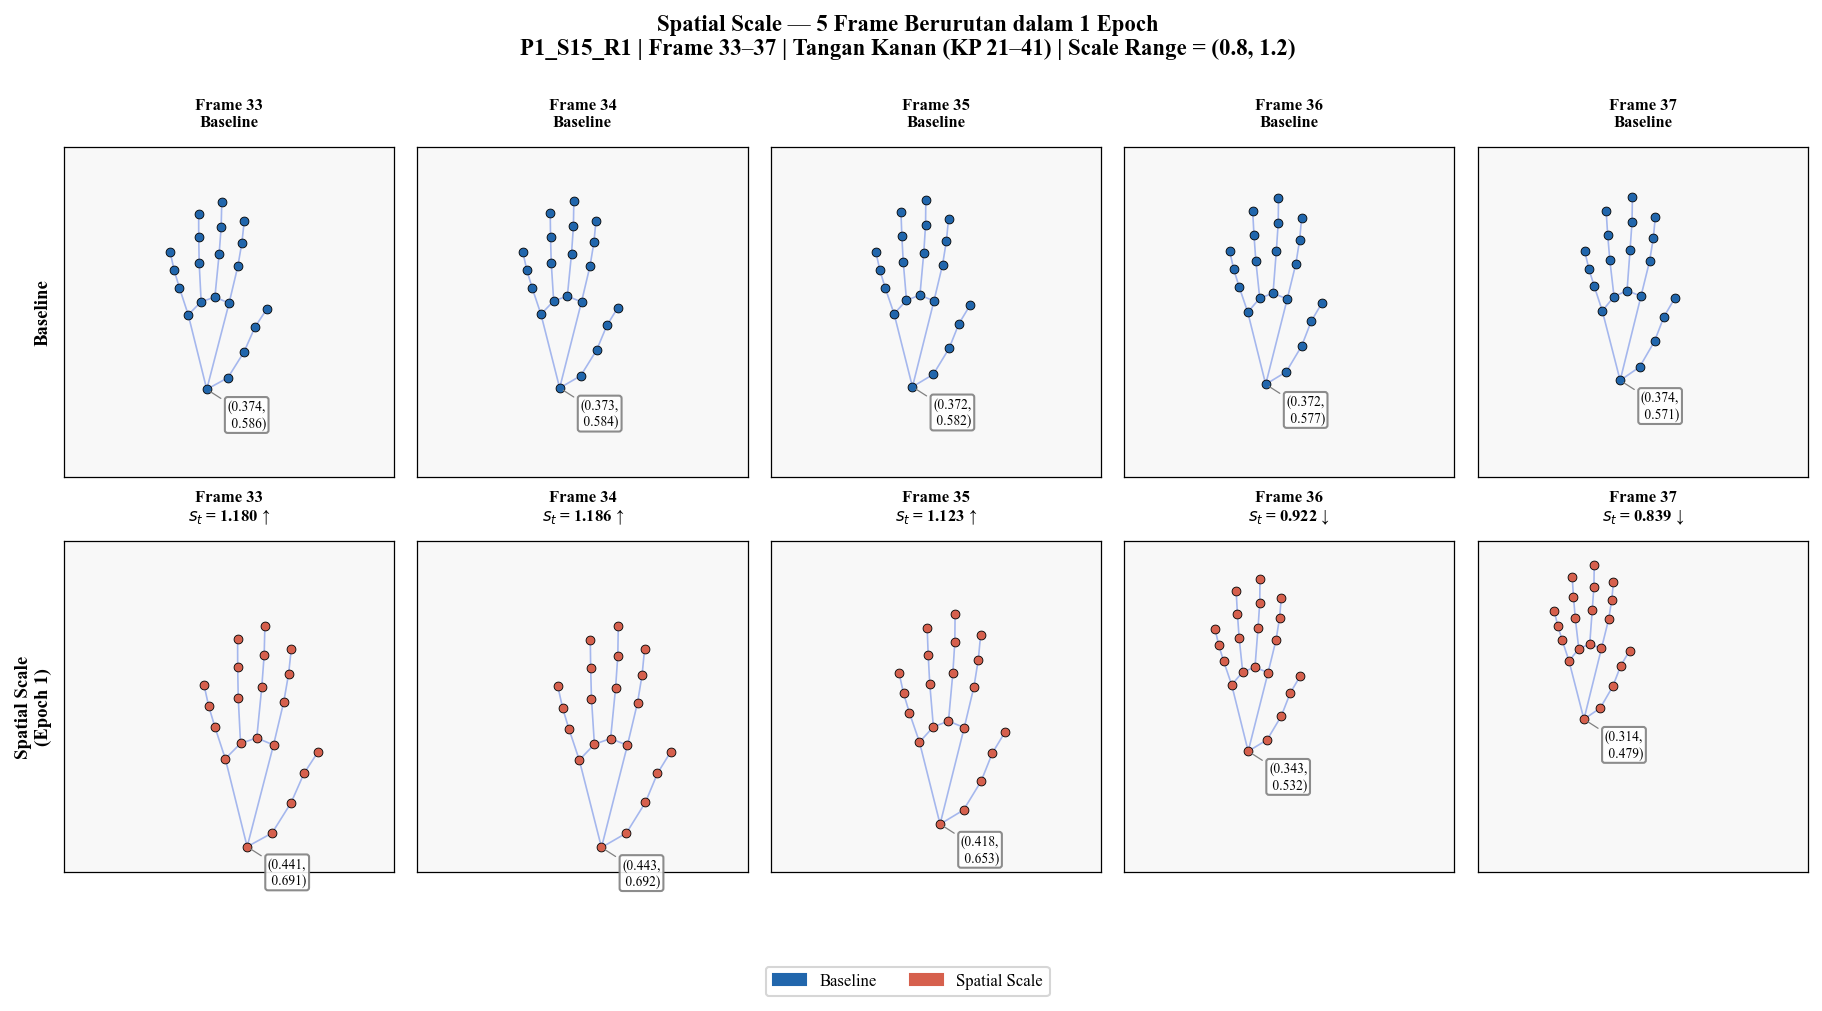

Saved: docs/spatial_scale_5frame_1epoch.png


In [18]:
def _draw_hand(ax, pts, color):
    # Skeleton
    for p1, p2 in HAND_CONNS:
        if pts[p1, 0] == 0 or pts[p2, 0] == 0:
            continue

        ax.plot(
            [pts[p1, 0], pts[p2, 0]],
            [pts[p1, 1], pts[p2, 1]],
            color="#4169E1",
            alpha=0.45,
            lw=0.8,
            zorder=1
        )

    valid = pts[:, 0] != 0

    # Semua keypoint tetap sama
    ax.scatter(
        pts[valid, 0],
        pts[valid, 1],
        c=color,
        s=18,
        edgecolors="black",
        linewidths=0.4,
        zorder=3
    )

    # ==========================
    # Tampilkan koordinat wrist
    # ==========================
    wrist = pts[0]

    if wrist[0] != 0:

        ax.annotate(
            f"({wrist[0]:.3f},\n {wrist[1]:.3f})",
            xy=(wrist[0], wrist[1]),
            xytext=(10, -5),
            textcoords="offset points",
            fontsize=6.5,
            color="black",
            ha="left",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="gray",
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.6
            ),
            zorder=5
        )


def shared_square_lim(list_of_rh, pad=0.04):
    all_pts = np.concatenate(list_of_rh, axis=0)
    valid = all_pts[all_pts[:, 0] != 0]

    x_min = valid[:, 0].min() - pad
    x_max = valid[:, 0].max() + pad
    y_min = valid[:, 1].min() - pad
    y_max = valid[:, 1].max() + pad

    span = max(x_max - x_min, y_max - y_min)

    x_mid = (x_min + x_max) / 2
    y_mid = (y_min + y_max) / 2

    return (
        (x_mid - span / 2, x_mid + span / 2),
        (y_mid - span / 2, y_mid + span / 2),
    )


def plot_panel(ax, rh_21, title, color, xlim, ylim):

    _draw_hand(ax, rh_21, color)

    wrist = rh_21[0]

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    ax.set_aspect("equal")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_facecolor("#F8F8F8")

    ax.set_title(
        title,
        fontsize=8,
        pad=10,
        fontweight="bold"
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)


# ==========================================================
# Data
# ==========================================================

rh_baseline = [skeleton[fi, 21:42] for fi in FRAME_INDICES]
rh_ep1 = [scaled_epoch1[fi, 21:42] for fi in FRAME_INDICES]
s_t_ep1 = [get_scale_factor(skeleton, scaled_epoch1, fi) for fi in FRAME_INDICES]

XLIM, YLIM = shared_square_lim(rh_baseline + rh_ep1)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6.6)
)

for col, fi in enumerate(FRAME_INDICES):

    s_t = s_t_ep1[col]

    direction = "↑" if s_t >= 1 else "↓"

    plot_panel(
        axes[0, col],
        rh_baseline[col],
        f"Frame {fi}\nBaseline",
        COLOR_BASELINE,
        XLIM,
        YLIM,
    )

    plot_panel(
        axes[1, col],
        rh_ep1[col],
        f"Frame {fi}\n$s_t$ = {s_t:.3f} {direction}",
        COLOR_SCALE,
        XLIM,
        YLIM,
    )


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=9,
    labelpad=6,
    fontweight="bold"
)

axes[1, 0].set_ylabel(
    "Spatial Scale\n(Epoch 1)",
    fontsize=9,
    labelpad=6,
    fontweight="bold"
)

fig.legend(
    handles=[
        mpatches.Patch(
            color=COLOR_BASELINE,
            label="Baseline"
        ),
        mpatches.Patch(
            color=COLOR_SCALE,
            label="Spatial Scale"
        ),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=8,
    frameon=True,
)

fig.suptitle(
    f"Spatial Scale — 5 Frame Berurutan dalam 1 Epoch\n"
    f"{SELECTED_ID} | Frame {FRAME_INDICES[0]}–{FRAME_INDICES[-1]} | "
    f"Tangan Kanan (KP 21–41) | Scale Range = {scale_aug.scale_range}",
    fontsize=11,
    fontweight="bold",
    y=0.98,
)

plt.subplots_adjust(
    top=0.86,
    bottom=0.10,
    wspace=0.07,
    hspace=0.10,
)

plt.savefig(
    "docs/spatial_scale_5frame_1epoch.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: docs/spatial_scale_5frame_1epoch.png")

## 7. Visualisasi — 5 Frame Berurutan pada 3 Epoch

Grid **4 baris × 5 kolom**: baris 1 = baseline, baris 2–4 = epoch 1–3.  
Menunjukkan bahwa frame yang sama mendapat $s_t$ berbeda di setiap epoch.

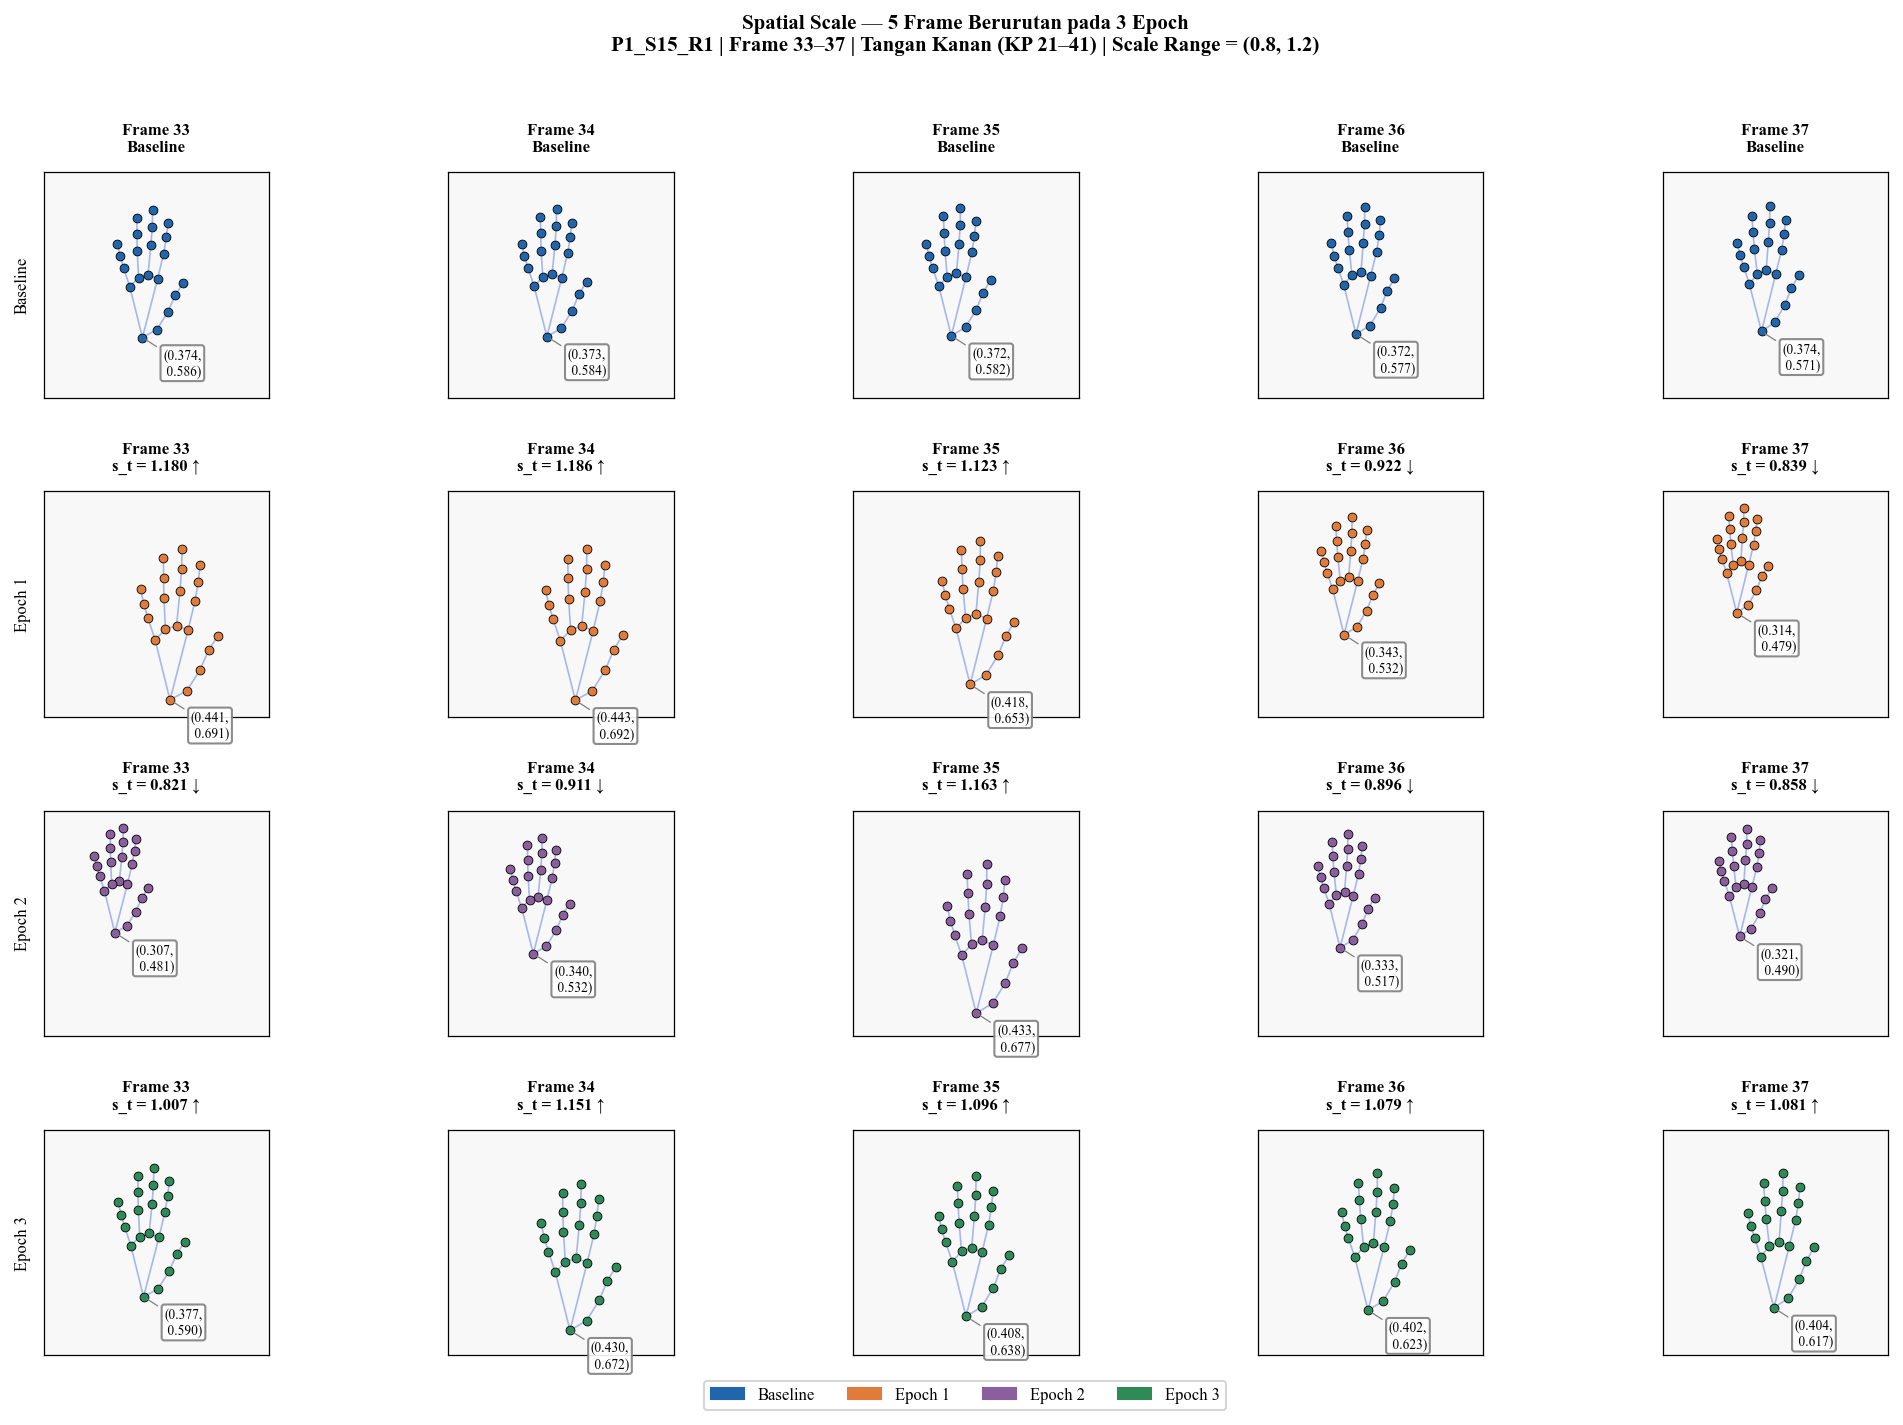

Saved: docs/spatial_scale_5frame_3epoch.png


In [19]:
N_VIZ_EPOCHS = 3
seqs_viz     = scaled_seqs[:N_VIZ_EPOCHS]   # epoch 1–3

# Kumpulkan semua rh untuk shared bbox
all_rh = rh_baseline.copy()
for seq in seqs_viz:
    all_rh += [seq[fi, 21:42] for fi in FRAME_INDICES]
XLIM2, YLIM2 = shared_square_lim(all_rh)

fig, axes = plt.subplots(N_VIZ_EPOCHS + 1, 5, figsize=(14, 9))

# Baris 0 — Baseline
for col, fi in enumerate(FRAME_INDICES):
    plot_panel(axes[0, col], skeleton[fi, 21:42],
               title=f'Frame {fi}\nBaseline',
               color=COLOR_BASELINE, xlim=XLIM2, ylim=YLIM2)
axes[0, 0].set_ylabel('Baseline', fontsize=8, labelpad=6)

# Baris 1–3 — Epoch 1–3
for ep_i, (seq, ep_color) in enumerate(zip(seqs_viz, EPOCH_COLORS), 1):
    for col, fi in enumerate(FRAME_INDICES):
        s_t = get_scale_factor(skeleton, seq, fi)
        direction = '↓' if s_t < 1 else '↑'
        plot_panel(axes[ep_i, col], seq[fi, 21:42],
                   title=f'Frame {fi}\ns_t = {s_t:.3f} {direction}',
                   color=ep_color, xlim=XLIM2, ylim=YLIM2)
    axes[ep_i, 0].set_ylabel(f'Epoch {ep_i}', fontsize=8, labelpad=6)

# Legenda
legend_handles = [
    mpatches.Patch(color=COLOR_BASELINE, label='Baseline'),
] + [
    mpatches.Patch(color=c, label=f'Epoch {i+1}')
    for i, c in enumerate(EPOCH_COLORS[:N_VIZ_EPOCHS])
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=N_VIZ_EPOCHS + 1, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.02)
)
fig.suptitle(
    f'Spatial Scale — 5 Frame Berurutan pada 3 Epoch\n'
    f'{SELECTED_ID} | Frame {FRAME_INDICES[0]}–{FRAME_INDICES[-1]} | '
    f'Tangan Kanan (KP 21–41) | Scale Range = {scale_aug.scale_range}',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/spatial_scale_5frame_3epoch.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/spatial_scale_5frame_3epoch.png')

## 8. Visualisasi Distribusi Faktor Skala

Tiga subplot:
- **(a)** Histogram distribusi $s_t$ dari simulasi banyak frame
- **(b)** Time-series $s_t$ per frame dalam satu sekuens (menunjukkan variasi antar frame)
- **(c)** $s_t$ frame yang sama (`TARGET_FRAME`) di banyak epoch (menunjukkan variasi antar epoch)

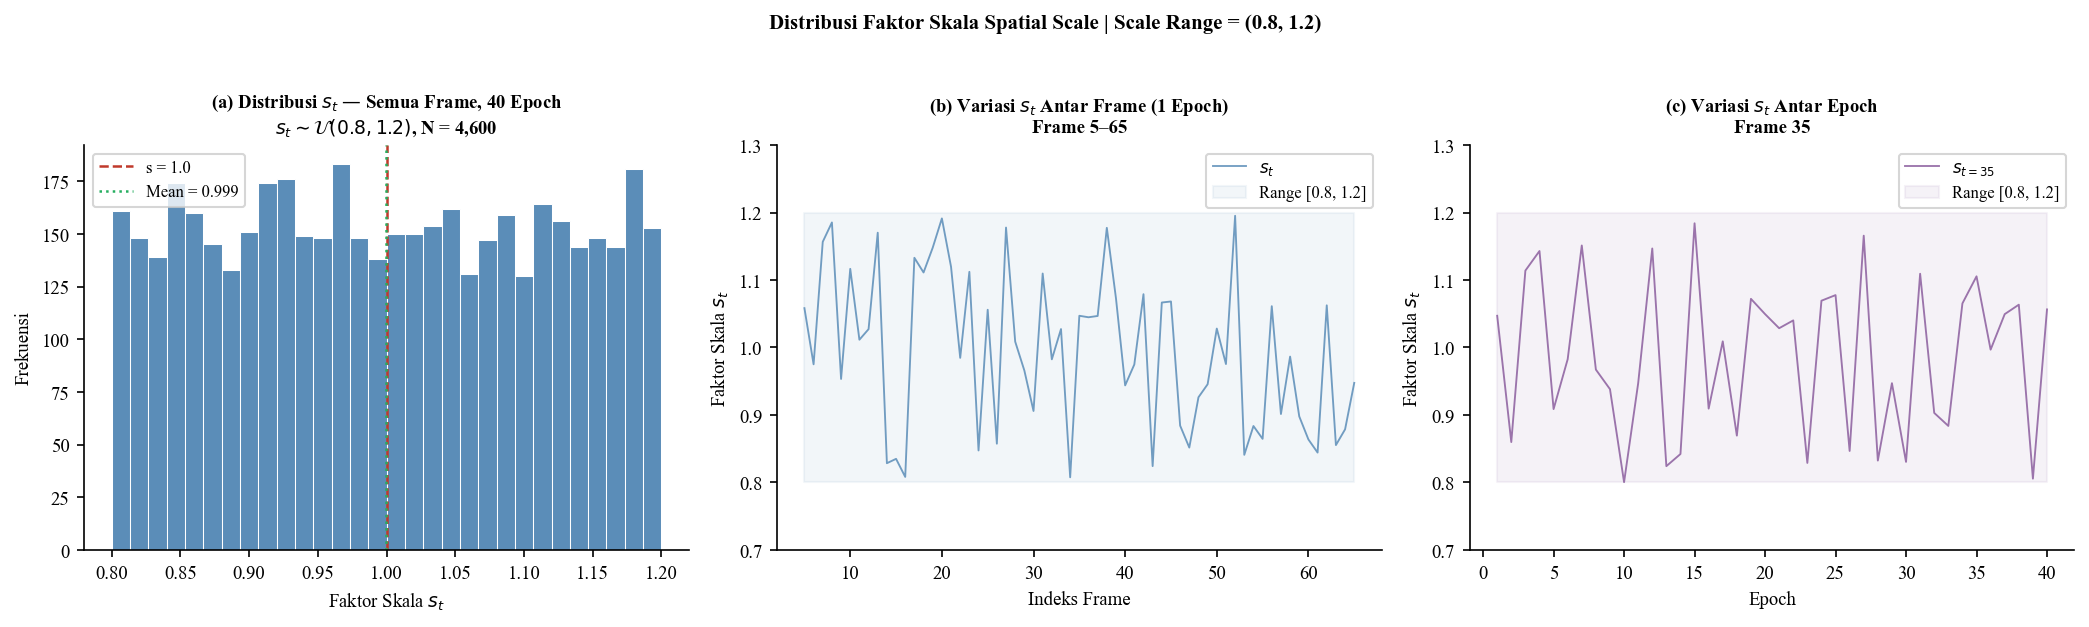

Saved: docs/spatial_scale_distribusi.png


In [16]:
T = skeleton.shape[0]
N_SIM = 40  # jumlah simulasi epoch

# =========================
# Simulasi faktor skala
# =========================
np.random.seed(0)

all_scales_flat = []
target_frame_s = []
one_epoch_series = None

for i in range(N_SIM):
    scales_i = np.random.uniform(0.8, 1.2, size=T)

    all_scales_flat.extend(scales_i)
    target_frame_s.append(scales_i[TARGET_FRAME])

    if i == 0:
        one_epoch_series = scales_i.copy()

all_scales_flat = np.array(all_scales_flat)
target_frame_s = np.array(target_frame_s)

# =========================
# Figure
# =========================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ==========================================================
# (a) Histogram distribusi seluruh s_t
# ==========================================================
ax = axes[0]

ax.hist(
    all_scales_flat,
    bins=30,
    color="#5B8DB8",
    edgecolor="white",
    lw=0.5
)

ax.axvline(
    1.0,
    color="#C0392B",
    lw=1.2,
    ls="--",
    label="s = 1.0"
)

ax.axvline(
    all_scales_flat.mean(),
    color="#27AE60",
    lw=1.2,
    ls=":",
    label=f"Mean = {all_scales_flat.mean():.3f}"
)

ax.set_xlabel("Faktor Skala $s_t$", fontsize=9)
ax.set_ylabel("Frekuensi", fontsize=9)

ax.set_title(
    f"(a) Distribusi $s_t$ — Semua Frame, {N_SIM} Epoch\n"
    f"$s_t \\sim \\mathcal{{U}}(0.8, 1.2)$, N = {len(all_scales_flat):,}",
    fontsize=9
)

ax.legend(fontsize=8)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

# ==========================================================
# (b) Variasi s_t antar frame (1 epoch)
# ==========================================================
ax2 = axes[1]

window = 30

start = max(0, TARGET_FRAME - window)
end = min(T, TARGET_FRAME + window + 1)

x = np.arange(start, end)

ax2.plot(
    x,
    one_epoch_series[start:end],
    color="#5B8DB8",
    lw=0.9,
    alpha=0.85,
    label="$s_t$"
)

ax2.fill_between(
    x,
    0.8,
    1.2,
    alpha=0.08,
    color="#5B8DB8",
    label="Range [0.8, 1.2]"
)

ax2.set_xlabel("Indeks Frame", fontsize=9)
ax2.set_ylabel("Faktor Skala $s_t$", fontsize=9)

ax2.set_title(
    f"(b) Variasi $s_t$ Antar Frame (1 Epoch)\n"
    f"Frame {start}–{end-1}",
    fontsize=9
)

ax2.set_ylim(0.70, 1.30)

ax2.legend(fontsize=8)

for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)

# ==========================================================
# (c) Variasi s_t frame TARGET_FRAME antar epoch
# ==========================================================
ax3 = axes[2]

epochs_show = N_SIM

ax3.plot(
    np.arange(1, epochs_show + 1),
    target_frame_s,
    color="#8B5E9E",
    lw=0.9,
    alpha=0.85,
    label=f"$s_{{t={TARGET_FRAME}}}$"
)

ax3.fill_between(
    np.arange(1, epochs_show + 1),
    0.8,
    1.2,
    alpha=0.08,
    color="#8B5E9E",
    label="Range [0.8, 1.2]"
)

ax3.set_xlabel("Epoch", fontsize=9)
ax3.set_ylabel("Faktor Skala $s_t$", fontsize=9)

ax3.set_title(
    f"(c) Variasi $s_t$ Antar Epoch\n"
    f"Frame {TARGET_FRAME}",
    fontsize=9
)

ax3.set_ylim(0.70, 1.30)

ax3.legend(fontsize=8)

for s in ["top", "right"]:
    ax3.spines[s].set_visible(False)

# ==========================================================
fig.suptitle(
    f"Distribusi Faktor Skala Spatial Scale | Scale Range = {scale_aug.scale_range}",
    fontsize=10,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    "docs/spatial_scale_distribusi.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: docs/spatial_scale_distribusi.png")